在12中,我们更加频繁的更新了模型的权重.但是对于一些持续上涨的状况,如铜价持续上涨,模型虽然把近期的误差纳入训练,但是等权MSE近期的误差占比仍然很小.因此,为了提高近期的影响,我们使用加权MSE进行实验.

# A 等权训练 vs B 加权 MSE（半衰期 60）

A：沿用12的逐月重训方案；复用前三个月验证所选的种子，把预测月之前全部可用数据纳入训练。B：同一训练集、同一种子、相同标准化器拟合方式及超参数，只更换训练损失。两阶段都采用对应损失，第一阶段冻结后以样本内预测训练第二阶段。

半衰期按 **60条有效日度记录**，不是60个日历日；数据一年有271条记录，因此也不直接称60个交易日。以每次训练集最新一条记录为年龄0，向前递增：

$$w_i=2^{-a_i/60},\qquad L_B=\frac{\sum_i w_i(\hat y_i-y_i)^2}{\sum_i w_i},\qquad L_A=\frac1N\sum_i(\hat y_i-y_i)^2.$$

损失在标准化目标上计算；归一化权重均值为1，避免仅因损失尺度变化改变优化强度。标准化仍等权拟合，避免同时更改预处理。保持16→32隐藏层、ReLU、Adam学习率0.01、全批量、两阶段各100轮，每月重新初始化。

为单独比较损失，不为B另选种子。复用A种子有利于配对控制，但本实验不能代表B独立调参后的最佳表现。以2020年相同日期普通MSE、MAPE比较；报告月度与全年结果，不以测试误差反向选择半衰期。

输入包含同日市场数据，这是历史同日股价拟合的样本外实验；2020年已被多次查看，不是新的盲测。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP13_OUT',str(ROOT/'results/mlp_weighted_mse_13')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)


HALF_LIFE=60
PRIOR=OUT.parent/'mlp_monthly_refit_12'
if not (PRIOR/'reused_selection.csv').exists(): PRIOR=ROOT/'results/mlp_monthly_refit_12'
selection=pd.read_csv(PRIOR/'reused_selection.csv')
previous=pd.read_csv(PRIOR/'stitched_comparison.csv',parse_dates=['Date'])
prior_config=json.loads((PRIOR/'config.json').read_text())
assert prior_config['dataset_sha256']==config['dataset_sha256']
config.update(half_life=HALF_LIFE,age_unit='valid observations',weight_normalization='sum(weights)',weighted_stages=['Base','Stacking'],scaler='unweighted StandardScaler',refit_after_selection=True,selection='reuse A seeds; no B reranking',selection_sha256=hashlib.sha256((PRIOR/'reused_selection.csv').read_bytes()).hexdigest())
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
selection.to_csv(OUT/'reused_selection.csv',index=False)


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    ages=np.arange(len(train_idx)-1,-1,-1)
    weights=np.ones(len(train_idx)) if METHOD=='A' else 2.0**(-ages/HALF_LIFE)
    wt=torch.tensor(weights/weights.mean(),dtype=torch.float32).reshape(-1,1)
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=(wt*(model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Method=METHOD,Month=month,Seed=seed,Stage=stage,Epoch=epoch,Weighted_MSE=float(np.average((p-y.loc[train_idx].to_numpy())**2,weights=weights)),Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{METHOD}_{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)



In [3]:
frames=[];splits=[];weight_rows=[]
for row in selection.itertuples(index=False):
    month=row.Month;seed=int(row.Selected_seed);start=pd.Timestamp(month+'-01');end=start+pd.DateOffset(months=1)
    tr=x.index[x.index<start];te=x.index[(x.index>=start)&(x.index<end)]
    assert tr.max()<te.min()
    ages=np.arange(len(tr)-1,-1,-1);w=2.0**(-ages/HALF_LIFE)
    assert np.isclose(w[-61]/w[-1],.5)
    weight_rows.append(dict(Month=month,N=len(tr),Effective_sample_size=w.sum()**2/(w*w).sum(),Recent60_weight_share=w[-60:].sum()/w.sum()))
    for split,idx in [('Train',tr),('Test',te)]:splits.append(dict(Month=month,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
    result=pd.DataFrame(dict(Date=te,Month=month,Seed=seed,Actual=y.loc[te].to_numpy()))
    for METHOD in ['A','B']:
        known=x.loc[tr]
        base=fit_stage(known[BASE],tr,seed,'Base',month)
        meta=known[RETURNS].copy();meta.insert(0,'base_prediction',predict(base,known[BASE]))
        stack=fit_stage(meta,tr,seed,'Stacking',month)
        result[METHOD]=stack_predict(base,stack,x.loc[te]).to_numpy()
    frames.append(result)
    print(month,'completed',flush=True)
comparison=pd.concat(frames,ignore_index=True)
assert comparison.Date.is_unique and pd.DatetimeIndex(comparison.Date).equals(whole)
assert np.allclose(comparison.A,previous.set_index('Date').loc[comparison.Date,'Refit_prediction'],rtol=0,atol=1e-6), 'A must reproduce prior monthly refit'
rows=[]
for month,g in comparison.groupby('Month'):
    r=dict(Month=month,N=len(g))
    for method in ['A','B']:
        err=g[method]-g.Actual
        r[method+'_MAPE']=100*(err.abs()/g.Actual.abs()).mean();r[method+'_MSE']=(err**2).mean()
    r['B_minus_A_MAPE_pp']=r['B_MAPE']-r['A_MAPE'];r['B_minus_A_MSE']=r['B_MSE']-r['A_MSE'];rows.append(r)
monthly=pd.DataFrame(rows)
summary=pd.DataFrame([dict(Method=method,Annual_MSE=((comparison[method]-comparison.Actual)**2).mean(),Annual_MAPE=100*((comparison[method]-comparison.Actual).abs()/comparison.Actual.abs()).mean(),Monthly_equal_MAPE=monthly[method+'_MAPE'].mean()) for method in ['A','B']])
assert len(history)==4800
for name,frame in [('predictions',comparison),('monthly_comparison',monthly),('summary',summary),('splits',pd.DataFrame(splits)),('weight_diagnostics',pd.DataFrame(weight_rows)),('training_history',pd.DataFrame(history))]:frame.to_csv(OUT/f'{name}.csv',index=False)
display(summary.round(5));display(monthly.round(5));display(pd.DataFrame(weight_rows).round(4))
print('B improves monthly MAPE:',int((monthly.B_minus_A_MAPE_pp<0).sum()),'/12')
print('A reproduction verified against 12; train/test chronology and half-life verified.')


,Method,Annual_MSE,Annual_MAPE,Monthly_equal_MAPE
0,A,0.33809,8.14992,8.15282
1,B,0.25027,6.65766,6.73328


,Month,N,A_MAPE,A_MSE,B_MAPE,B_MSE,B_minus_A_MAPE_pp,B_minus_A_MSE
0,2020-01,24,8.46359,0.17072,5.41813,0.08200,-3.04546,-0.08872
1,2020-02,21,6.28027,0.09135,9.12746,0.18983,2.84719,0.09848
2,2020-03,22,10.84908,0.26235,5.63887,0.07003,-5.21021,-0.19231
3,2020-04,23,7.38192,0.12098,3.02372,0.02325,-4.35820,-0.09773
4,2020-05,23,4.24132,0.03969,4.28797,0.04238,0.04665,0.00269
5,2020-06,23,9.28895,0.15408,6.66233,0.09103,-2.62662,-0.06305
6,2020-07,23,14.01698,0.73172,7.17390,0.22510,-6.84309,-0.50662
7,2020-08,21,5.47506,0.17177,9.14712,0.43597,3.67206,0.26420
8,2020-09,24,11.49300,0.69790,6.28722,0.23293,-5.20578,-0.46497
9,2020-10,23,3.69089,0.08192,6.62530,0.22484,2.93440,0.14292


,Month,N,Effective_sample_size,Recent60_weight_share
0,2020-01,2035,173.1253,0.5
1,2020-02,2059,173.1253,0.5
2,2020-03,2080,173.1253,0.5
3,2020-04,2102,173.1253,0.5
4,2020-05,2125,173.1253,0.5
5,2020-06,2148,173.1253,0.5
6,2020-07,2171,173.1253,0.5
7,2020-08,2194,173.1253,0.5
8,2020-09,2215,173.1253,0.5
9,2020-10,2239,173.1253,0.5


2020-01 completed
2020-02 completed
2020-03 completed
2020-04 completed
2020-05 completed
2020-06 completed
2020-07 completed
2020-08 completed
2020-09 completed
2020-10 completed
2020-11 completed
2020-12 completed
B improves monthly MAPE: 7 /12
A reproduction verified against 12; train/test chronology and half-life verified.


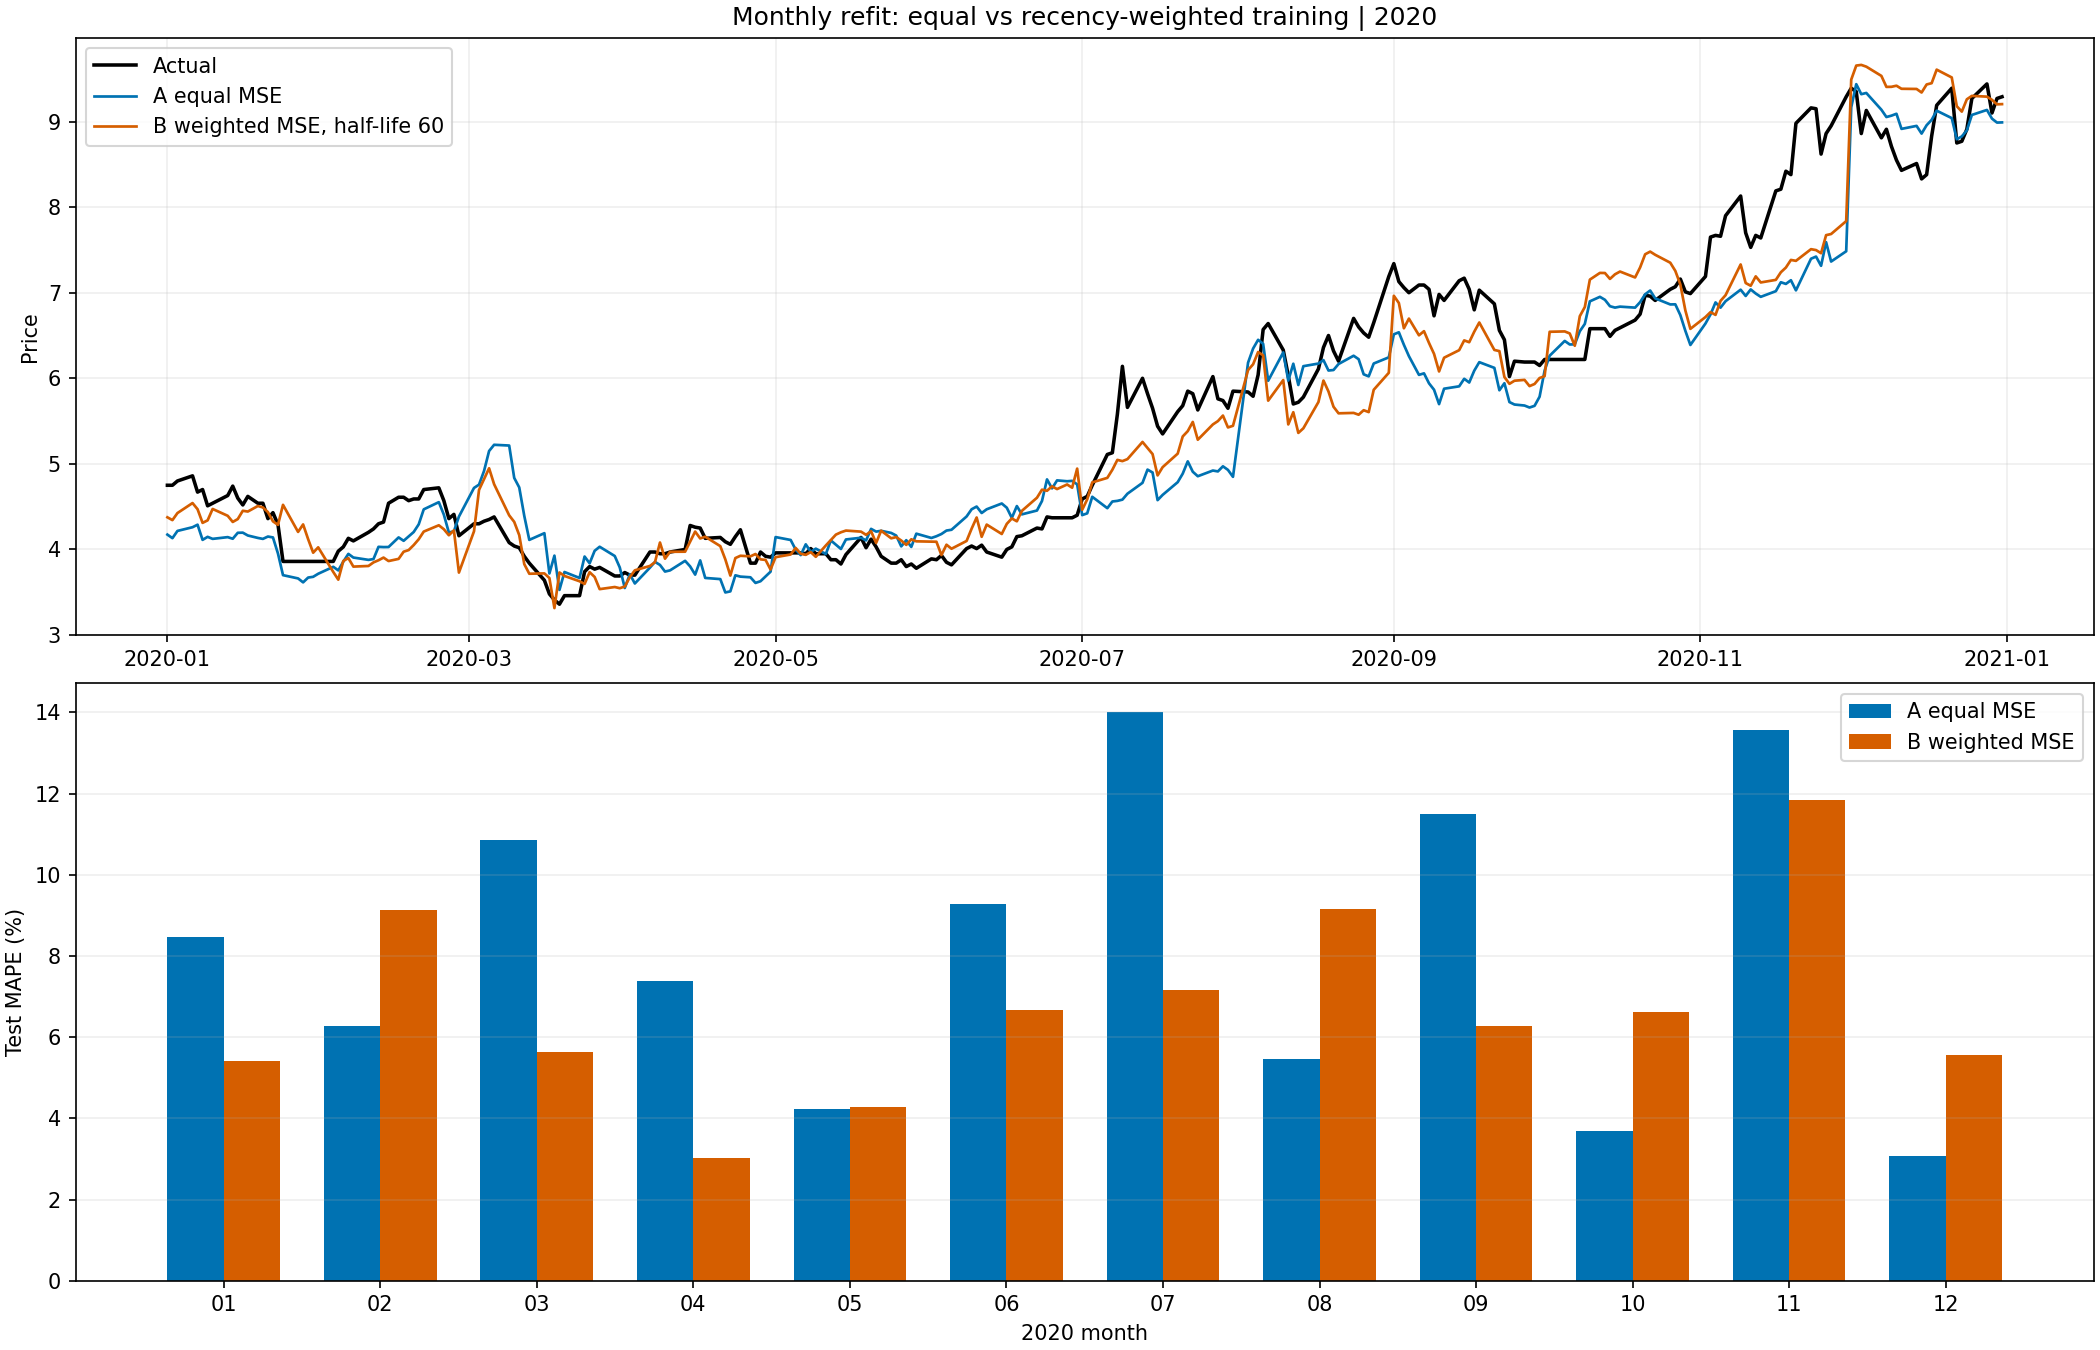

In [4]:
fig,axes=plt.subplots(2,1,figsize=(14,9),constrained_layout=True)
axes[0].plot(comparison.Date,comparison.Actual,color='black',label='Actual',lw=1.7)
for method,color in [('A','#0072B2'),('B','#D55E00')]:
    axes[0].plot(comparison.Date,comparison[method],label=method+(' equal MSE' if method=='A' else ' weighted MSE, half-life 60'),color=color,lw=1.3)
axes[0].set(title='Monthly refit: equal vs recency-weighted training | 2020',ylabel='Price');axes[0].legend();axes[0].grid(alpha=.2)
p=np.arange(12)
axes[1].bar(p-.18,monthly.A_MAPE,width=.36,label='A equal MSE',color='#0072B2');axes[1].bar(p+.18,monthly.B_MAPE,width=.36,label='B weighted MSE',color='#D55E00')
axes[1].set(xticks=p,xticklabels=monthly.Month.str[-2:],ylabel='Test MAPE (%)',xlabel='2020 month');axes[1].legend();axes[1].grid(axis='y',alpha=.2)
fig.savefig(OUT/'comparison.png',dpi=150);plt.close(fig);display(Image(filename=str(OUT/'comparison.png')))


## 本次结果

| 测试指标 | A 等权 MSE | B 加权 MSE（60） |
|---|---:|---:|
| 全年逐记录 MAPE | 8.1499% | 6.6577% |
| 全年普通 MSE | 0.338087 | 0.250269 |
| 12个月等权平均 MAPE | 8.1528% | 6.7333% |

B全年MAPE下降1.4923个百分点（相对下降18.31%），普通MSE下降25.98%。7/12个月的MAPE改善，7月改善最大（14.02%→7.17%），8月退步最大（5.48%→9.15%）；2、5、8、10、12月误差上升。

**结论：在固定A种子、固定100轮等条件下，半衰期60的加权训练改善了2020年的总体误差，但并非逐月稳定改善。** 这不足以证明60是最优半衰期，也不能仅凭误差改善断言具体由铜价趋势引起。后续比较保留A作为统一基准。

验证已通过：A复现12中原预测（绝对容差1e-6）；每月训练截止日期严格早于测试；60条记录权重减半；271条测试记录日期唯一且对齐；共4800条逐轮训练记录。


看来加上近期的修正后,总体的误差得以改善.我们再尝试一下不同的半衰期.此外可以看出,一个月更新一次仍然会有较明显的跳变问题.

# 扩展比较：半衰期30、60、120、240与等权A

延续上一节控制条件，新增30、120、240条有效日度记录的半衰期。复用A和60的已验证预测；每月仍使用同一既定种子、月前全部历史、两阶段各100轮、等权标准化，仅改变两阶段损失的时间权重。B不单独重新选择种子。

统一用同一271条2020年测试记录计算普通MSE与MAPE，同时报告12个月等权MAPE、相对A改善月份数、最差月份MAPE。不同方案的加权训练损失不可直接横向作为优劣依据。2020年结果仅用于探索，不能据此证明最优半衰期能泛化到未参与选择的年份。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP13_GRID_OUT',str(ROOT/'results/mlp_half_life_comparison_13')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)


HALF_LIFE=60
PRIOR=OUT.parent/'mlp_monthly_refit_12'
if not (PRIOR/'reused_selection.csv').exists(): PRIOR=ROOT/'results/mlp_monthly_refit_12'
selection=pd.read_csv(PRIOR/'reused_selection.csv')
previous=pd.read_csv(PRIOR/'stitched_comparison.csv',parse_dates=['Date'])
prior_config=json.loads((PRIOR/'config.json').read_text())
assert prior_config['dataset_sha256']==config['dataset_sha256']
config.update(half_life=HALF_LIFE,age_unit='valid observations',weight_normalization='sum(weights)',weighted_stages=['Base','Stacking'],scaler='unweighted StandardScaler',refit_after_selection=True,selection='reuse A seeds; no B reranking',selection_sha256=hashlib.sha256((PRIOR/'reused_selection.csv').read_bytes()).hexdigest())
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
selection.to_csv(OUT/'reused_selection.csv',index=False)

config.update(half_lives=[30,60,120,240],reused_methods=['A','H60'])
config.pop('half_life',None)
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
CACHED=OUT.parent/'mlp_weighted_mse_13'
if not (CACHED/'predictions.csv').exists(): CACHED=ROOT/'results/mlp_weighted_mse_13'
cached_config=json.loads((CACHED/'config.json').read_text())
assert cached_config['dataset_sha256']==config['dataset_sha256']
assert cached_config['selection_sha256']==config['selection_sha256']
comparison=pd.read_csv(CACHED/'predictions.csv',parse_dates=['Date']).rename(columns={'B':'H60'})
assert pd.DatetimeIndex(comparison.Date).equals(whole)
assert np.allclose(comparison.Actual,y.loc[whole])
config['cached_predictions_sha256']=hashlib.sha256((CACHED/'predictions.csv').read_bytes()).hexdigest()
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    ages=np.arange(len(train_idx)-1,-1,-1)
    weights=np.ones(len(train_idx)) if METHOD=='A' else 2.0**(-ages/HALF_LIFE)
    wt=torch.tensor(weights/weights.mean(),dtype=torch.float32).reshape(-1,1)
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=(wt*(model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Method=METHOD,Month=month,Seed=seed,Stage=stage,Epoch=epoch,Weighted_MSE=float(np.average((p-y.loc[train_idx].to_numpy())**2,weights=weights)),Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{METHOD}_{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)



In [3]:
splits=[];weight_rows=[]
for HALF_LIFE in [30,120,240]:
    METHOD=f'H{HALF_LIFE}';frames=[]
    for row in selection.itertuples(index=False):
        month=row.Month;seed=int(row.Selected_seed);start=pd.Timestamp(month+'-01');end=start+pd.DateOffset(months=1)
        tr=x.index[x.index<start];te=x.index[(x.index>=start)&(x.index<end)]
        assert tr.max()<te.min()
        ages=np.arange(len(tr)-1,-1,-1);w=2.0**(-ages/HALF_LIFE)
        assert np.isclose(w[-HALF_LIFE-1]/w[-1],.5)
        weight_rows.append(dict(Method=METHOD,Month=month,N=len(tr),Effective_sample_size=w.sum()**2/(w*w).sum(),Recent60_weight_share=w[-60:].sum()/w.sum()))
        for split,idx in [('Train',tr),('Test',te)]:splits.append(dict(Method=METHOD,Month=month,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
        known=x.loc[tr];base=fit_stage(known[BASE],tr,seed,'Base',month)
        meta=known[RETURNS].copy();meta.insert(0,'base_prediction',predict(base,known[BASE]))
        stack=fit_stage(meta,tr,seed,'Stacking',month)
        frames.append(pd.DataFrame({'Date':te,METHOD:stack_predict(base,stack,x.loc[te]).to_numpy()}))
    pred=pd.concat(frames,ignore_index=True)
    comparison=comparison.merge(pred,on='Date',validate='one_to_one')
    print(METHOD,'12 months completed',flush=True)
assert len(history)==7200 and len(comparison)==271
METHODS=['A','H30','H60','H120','H240']
rows=[]
for month,g in comparison.groupby('Month'):
    for method in METHODS:
        err=g[method]-g.Actual
        rows.append(dict(Month=month,Method=method,N=len(g),MAPE=100*(err.abs()/g.Actual.abs()).mean(),MSE=(err**2).mean()))
monthly=pd.DataFrame(rows)
base_month=monthly[monthly.Method=='A'].set_index('Month')
monthly['MAPE_minus_A_pp']=monthly.MAPE-monthly.Month.map(base_month.MAPE)
monthly['MSE_minus_A']=monthly.MSE-monthly.Month.map(base_month.MSE)
rows=[]
for method in METHODS:
    g=monthly[monthly.Method==method];err=comparison[method]-comparison.Actual;worst=g.loc[g.MAPE.idxmax()]
    rows.append(dict(Method=method,Annual_MSE=(err**2).mean(),Annual_MAPE=100*(err.abs()/comparison.Actual.abs()).mean(),Monthly_equal_MAPE=g.MAPE.mean(),Months_MAPE_better_than_A=int((g.MAPE_minus_A_pp<0).sum()),Months_MSE_better_than_A=int((g.MSE_minus_A<0).sum()),Worst_month=worst.Month,Worst_month_MAPE=worst.MAPE))
summary=pd.DataFrame(rows)
summary['MSE_reduction_vs_A_pct']=100*(1-summary.Annual_MSE/summary.iloc[0].Annual_MSE)
summary['MAPE_reduction_vs_A_pp']=summary.iloc[0].Annual_MAPE-summary.Annual_MAPE
for method,old in [('A','A'),('H60','B')]:
    cached_summary=pd.read_csv(CACHED/'summary.csv').set_index('Method')
    assert np.isclose(summary.set_index('Method').loc[method,'Annual_MAPE'],cached_summary.loc[old,'Annual_MAPE'])
for name,frame in [('predictions',comparison),('monthly_comparison',monthly),('summary',summary),('splits',pd.DataFrame(splits)),('weight_diagnostics',pd.DataFrame(weight_rows)),('training_history',pd.DataFrame(history))]:frame.to_csv(OUT/f'{name}.csv',index=False)
display(summary.round(5));display(monthly.pivot(index='Month',columns='Method',values='MAPE')[METHODS].round(4))
print('Verified: identical test dates and seeds; strict train/test chronology; half-life ratios; cached A and H60 metrics; 7200 new training records.')


,Method,Annual_MSE,Annual_MAPE,Monthly_equal_MAPE,Months_MAPE_better_than_A,Months_MSE_better_than_A,Worst_month,Worst_month_MAPE,MSE_reduction_vs_A_pct,MAPE_reduction_vs_A_pp
0,A,0.33809,8.14992,8.15282,0,0,2020-07,14.01698,0.00000,0.00000
1,H30,0.30173,7.24232,7.32659,6,6,2020-07,14.31399,10.75246,0.90761
2,H60,0.25027,6.65766,6.73328,7,7,2020-11,11.83856,25.97487,1.49226
3,H120,0.31525,7.19927,7.27848,8,8,2020-11,13.06308,6.75434,0.95065
4,H240,0.31576,7.18515,7.23373,8,8,2020-11,12.72767,6.60457,0.96477


Method,A,H30,H60,H120,H240
Month,,,,,
2020-01,8.4636,5.2222,5.4181,7.0414,2.8423
2020-02,6.2803,8.7127,9.1275,11.8474,8.3325
2020-03,10.8491,7.4416,5.6389,9.1178,8.6104
2020-04,7.3819,3.0859,3.0237,2.8896,3.3405
2020-05,4.2413,4.3607,4.2880,2.8454,2.8184
2020-06,9.2889,5.9555,6.6623,3.7756,9.3388
2020-07,14.0170,14.3140,7.1739,9.2999,9.1303
2020-08,5.4751,9.3918,9.1471,6.6209,5.2165
2020-09,11.4930,4.7254,6.2872,7.2786,8.9893


H30 12 months completed
H120 12 months completed
H240 12 months completed
Verified: identical test dates and seeds; strict train/test chronology; half-life ratios; cached A and H60 metrics; 7200 new training records.


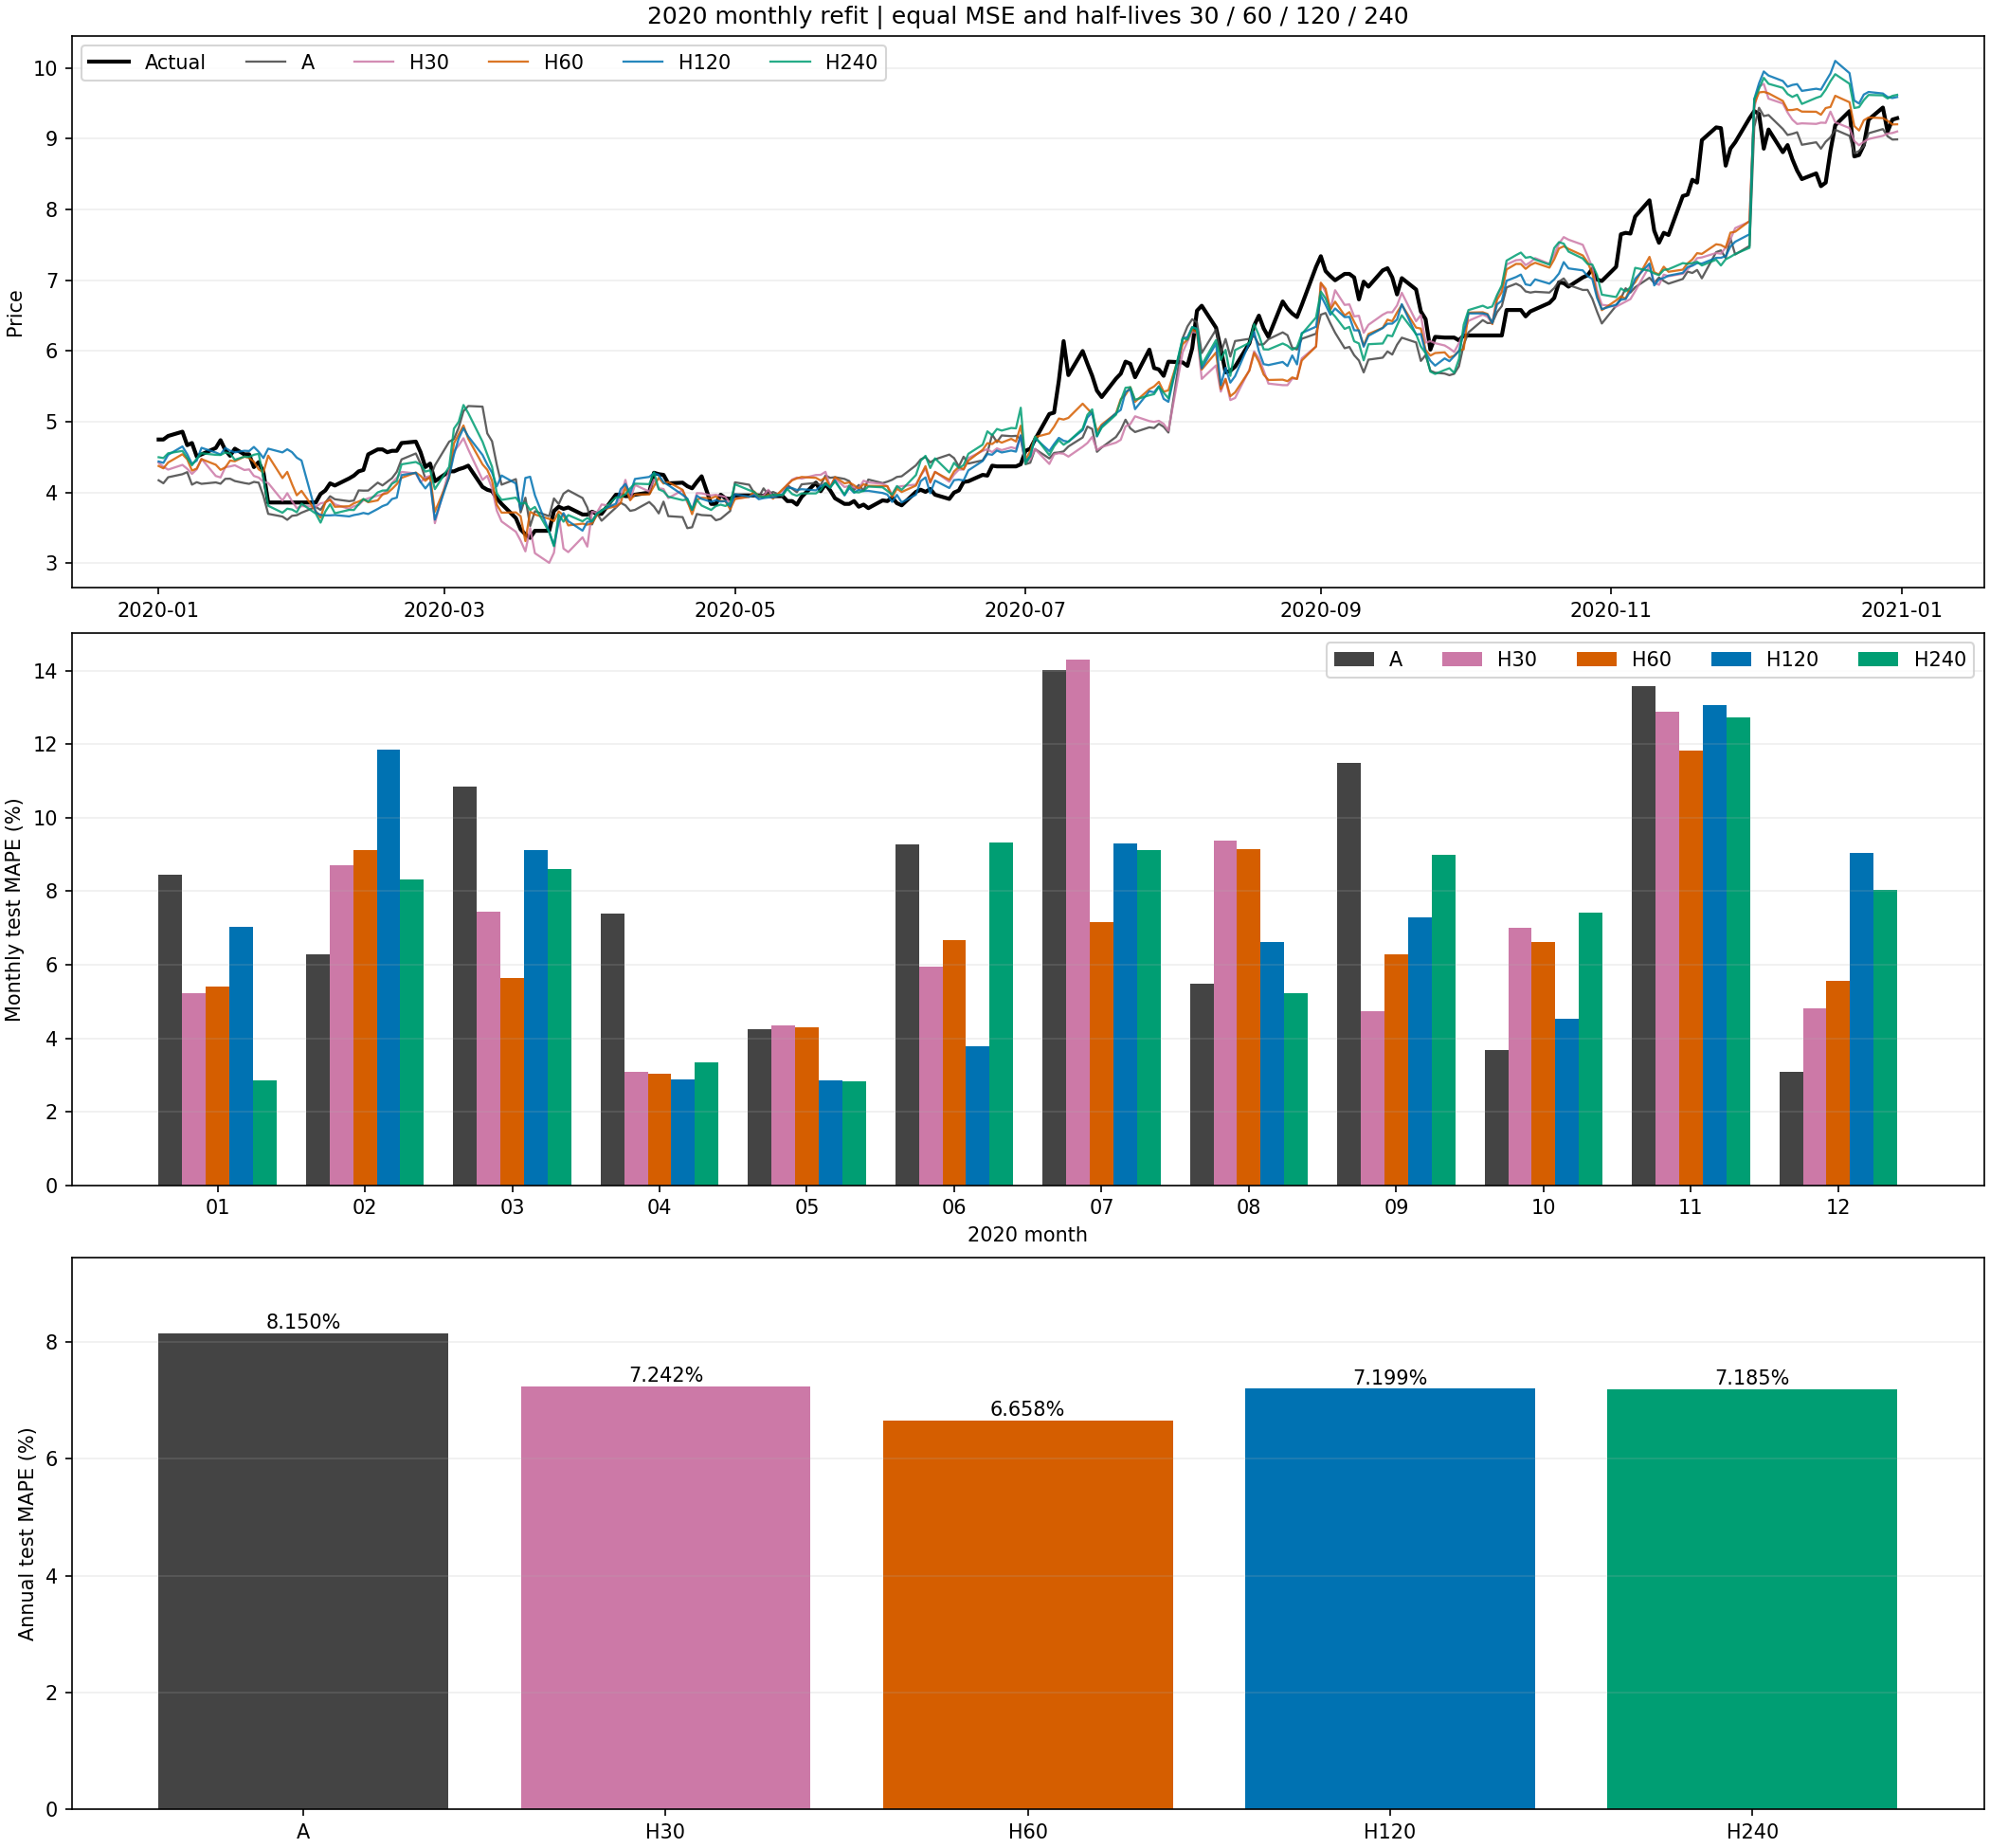

In [4]:
colors={'A':'#444444','H30':'#CC79A7','H60':'#D55E00','H120':'#0072B2','H240':'#009E73'}
fig,axes=plt.subplots(3,1,figsize=(14,13),constrained_layout=True)
axes[0].plot(comparison.Date,comparison.Actual,color='black',lw=2,label='Actual')
for method in METHODS:axes[0].plot(comparison.Date,comparison[method],color=colors[method],lw=1.1,label=method,alpha=.85)
axes[0].set(title='2020 monthly refit | equal MSE and half-lives 30 / 60 / 120 / 240',ylabel='Price');axes[0].legend(ncol=6)
p=np.arange(12)
for j,method in enumerate(METHODS):
    g=monthly[monthly.Method==method]
    axes[1].bar(p+(j-2)*.16,g.MAPE,width=.16,color=colors[method],label=method)
axes[1].set(xticks=p,xticklabels=g.Month.str[-2:],ylabel='Monthly test MAPE (%)',xlabel='2020 month');axes[1].legend(ncol=5)
axes[2].bar(summary.Method,summary.Annual_MAPE,color=[colors[m] for m in METHODS])
for i,v in enumerate(summary.Annual_MAPE):axes[2].text(i,v+.08,f'{v:.3f}%',ha='center')
axes[2].set(ylabel='Annual test MAPE (%)',ylim=(0,summary.Annual_MAPE.max()*1.16))
for ax in axes:ax.grid(axis='y',alpha=.2)
fig.savefig(OUT/'comparison.png',dpi=150);plt.close(fig);display(Image(filename=str(OUT/'comparison.png')))


## 半衰期比较结果与判断

| 方案 | 全年MAPE | 全年普通MSE | MAPE优于A月份数 | 最差月份MAPE |
|---|---:|---:|---:|---:|
| A 等权 | 8.1499% | 0.338087 | — | 14.0170% |
| 30 | 7.2423% | 0.301734 | 6/12 | 14.3140% |
| 60 | **6.6577%** | **0.250269** | 7/12 | **11.8386%** |
| 120 | 7.1993% | 0.315252 | 8/12 | 13.0631% |
| 240 | 7.1852% | 0.315758 | 8/12 | 12.7277% |

**60在本轮四个半衰期中表现最好**：全年MAPE、普通MSE、12个月等权MAPE及最差月份MAPE均最低。相对A，全年MAPE下降1.4923个百分点，普通MSE下降25.97%。

120、240虽然都有8个月优于A，但改善月份更多不等于全年总误差更低。30在7月MAPE为14.31%，比A还高；120和240在12月分别达到9.04%与8.03%，明显高于A的3.08%，这是延长半衰期未能持续改善的具体例子。

本轮暂保留60为后续加权训练参照，A仍作为统一等权基准。不自动增加更多半衰期搜索。结论限定于当前固定种子、100轮、同日输入的2020年开发实验，不能解释为60是普遍最优值。

新增三组共完成72个阶段模型、7200条逐轮记录；A和60复用上一节预测并校验指标。测试日期、数据指纹、种子选择记录与训练时间边界检查均通过。


目前看来是60的半衰期最好,但并不确定.我们先默认用60的半衰期.再用多次修正加加权MSE计算一下.

# 半衰期60：金铜MA20±3%双向穿越更新 vs 每月更新

沿用12的双向触发规则：金或铜任一的 `abs(P/MA20-1)` 在 `<3%` 与 `>=3%` 两种状态之间转换即触发；同日信号合并，无冷却期。持续超出不重复触发；从+4%直接到-4%仍属区间外，不额外推断盘中穿越。触发当天用旧模型，下条有效记录才使用新模型，训练标签最多到触发日。

两种更新方式均采用半衰期60条有效日度记录、两阶段加权MSE、等权标准化、16→32隐藏层、ReLU、Adam 0.01、全批量各100轮，从头重训。主对比为：M60 每月更新，E60 3%双向穿越更新。

**种子控制**：为延续本章月度60的口径，M60复用上一节结果；E60复用12中每次事件根据此前三个月验证MAPE选出的种子，仅将最终重训损失改为半衰期60，不重新运行候选选择。两种策略都沿用各自旧的等权候选选择记录，因此这是固定选种规则下的更新策略比较，不是同一种子贯穿全年的纯频率实验，也不是加权候选重新调参后的比较。

补充保留A月度等权、E等权双向触发的历史结果，便于区分损失变化和更新策略变化。年初初始化单列，事件次数和月度次数按相同口径报告。仍为2020年同日输入的历史开发实验。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP13_CROSS60_OUT',str(ROOT/'results/mlp_crossing_h60_13')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)

THRESHOLD=.03
config.update(trigger='individual metal abs(MA20 deviation) crosses outward or inward at 3%; same-date events merged',threshold=THRESHOLD,effective='next available record',refit_after_selection=True,validation_window='three calendar months immediately before effective date',cooldown=None)
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
# 在完整历史计算状态，使2020年初状态继承自2019年；只执行2020年触发。
deviations=x[['gold_vs_ma20','copper_vs_ma20']]
outside=deviations.abs().ge(THRESHOLD)
previous=outside.shift(1)
valid_previous=previous.notna().all(axis=1)
entry=outside & previous.eq(False)
reentry=~outside & previous.eq(True)
crossing=(entry|reentry)&valid_previous.to_numpy()[:,None]
trigger_dates=reentry.index[(crossing.any(axis=1))&(reentry.index.year==2020)]
eventrows=[]
for day in trigger_dates:
    pos=x.index.get_loc(day);nextday=x.index[pos+1] if pos+1<len(x) else pd.NaT
    executable=pd.notna(nextday) and nextday.year==2020
    eventrows.append(dict(Trigger_date=day,Effective_date=nextday,Gold_trigger=bool(crossing.loc[day,'gold_vs_ma20']),Copper_trigger=bool(crossing.loc[day,'copper_vs_ma20']),Gold_direction=('outward' if entry.loc[day,'gold_vs_ma20'] else 'inward' if reentry.loc[day,'gold_vs_ma20'] else ''),Copper_direction=('outward' if entry.loc[day,'copper_vs_ma20'] else 'inward' if reentry.loc[day,'copper_vs_ma20'] else ''),Gold_deviation_percent=100*deviations.loc[day,'gold_vs_ma20'],Copper_deviation_percent=100*deviations.loc[day,'copper_vs_ma20'],Executable_in_2020=executable))
events=pd.DataFrame(eventrows)
events.to_csv(OUT/'trigger_events.csv',index=False)
schedule=[dict(Update_ID='initial',Kind='Initial',Trigger_date=pd.NaT,Effective_date=whole.min())]
for i,r in enumerate(events[events.Executable_in_2020].itertuples(index=False),1):
    schedule.append(dict(Update_ID=f'update_{i:02d}',Kind='Triggered',Trigger_date=r.Trigger_date,Effective_date=r.Effective_date))
schedule=pd.DataFrame(schedule).sort_values('Effective_date').reset_index(drop=True)
assert schedule.Effective_date.is_unique
print(f'触发日 {len(events)} 次；年内计划更新 {len(schedule)-1} 次；另有年初初始化1次。')
display(events)

HALF_LIFE=60;METHOD='E60'
PRIOR=OUT.parent/'mlp_crossing_update_12'
if not (PRIOR/'updates.csv').exists():PRIOR=ROOT/'results/mlp_crossing_update_12'
MONTHLY=OUT.parent/'mlp_weighted_mse_13'
if not (MONTHLY/'predictions.csv').exists():MONTHLY=ROOT/'results/mlp_weighted_mse_13'
old_updates=pd.read_csv(PRIOR/'updates.csv',parse_dates=['Effective_date'])
prior_cfg=json.loads((PRIOR/'config.json').read_text());month_cfg=json.loads((MONTHLY/'config.json').read_text())
assert prior_cfg['dataset_sha256']==month_cfg['dataset_sha256']==config['dataset_sha256']
assert old_updates.Update_ID.tolist()==schedule.Update_ID.tolist()
assert old_updates.Effective_date.tolist()==schedule.Effective_date.tolist()
config.update(half_life=60,age_unit='valid observations',weight_normalization='sum(weights)',weighted_stages=['Base','Stacking'],scaler='unweighted StandardScaler',selection='reuse historical equal-MSE validation-selected event seeds; no reranking',source_updates_sha256=hashlib.sha256((PRIOR/'updates.csv').read_bytes()).hexdigest())
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
old_updates.to_csv(OUT/'reused_selection.csv',index=False)


,Trigger_date,Effective_date,Gold_trigger,Copper_trigger,Gold_direction,Copper_direction,Gold_deviation_percent,Copper_deviation_percent,Executable_in_2020
0,2020-01-03,2020-01-06,True,False,outward,,3.781956,-0.699238,True
1,2020-01-09,2020-01-10,True,False,inward,,2.612086,-0.349417,True
2,2020-01-23,2020-01-24,False,True,,outward,1.018186,-3.216644,True
3,2020-02-11,2020-02-12,False,True,,inward,-0.023948,-2.475336,True
4,2020-02-21,2020-02-24,True,False,outward,,3.884455,1.281281,True
5,2020-02-26,2020-02-27,True,False,inward,,2.854205,-0.374539,True
6,2020-03-05,2020-03-06,True,False,outward,,3.376295,-0.644862,True
7,2020-03-10,2020-03-11,True,False,inward,,1.984865,-2.341254,True
8,2020-03-12,2020-03-13,False,True,,outward,-2.524139,-3.778798,True
9,2020-03-13,2020-03-16,True,False,outward,,-6.797278,-3.842026,True


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
触发日 58 次；年内计划更新 58 次；另有年初初始化1次。


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    ages=np.arange(len(train_idx)-1,-1,-1)
    weights=np.ones(len(train_idx)) if METHOD=='A' else 2.0**(-ages/HALF_LIFE)
    wt=torch.tensor(weights/weights.mean(),dtype=torch.float32).reshape(-1,1)
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=(wt*(model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Method=METHOD,Month=month,Seed=seed,Stage=stage,Epoch=epoch,Weighted_MSE=float(np.average((p-y.loc[train_idx].to_numpy())**2,weights=weights)),Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{METHOD}_{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)



In [3]:
frames=[];splitrows=[];updates=[];jumps=[];previous_bundle=None
for j,row in enumerate(schedule.itertuples(index=False)):
    tag=row.Update_ID;effective=pd.Timestamp(row.Effective_date)
    stop=pd.Timestamp(schedule.iloc[j+1].Effective_date) if j+1<len(schedule) else pd.Timestamp('2021-01-01')
    tr=x.index[x.index<effective];applied=x.index[(x.index>=effective)&(x.index<stop)]
    prior=old_updates.loc[old_updates.Update_ID==tag].iloc[0];seed=int(prior.Selected_seed)
    assert tr.max()<applied.min() and pd.Timestamp(prior.Refit_train_end)==tr.max()
    if row.Kind=='Triggered':assert tr.max()==row.Trigger_date and x.index[x.index.get_loc(row.Trigger_date)+1]==effective
    known=x.loc[tr];base=fit_stage(known[BASE],tr,seed,'Base',tag)
    meta=known[RETURNS].copy();meta.insert(0,'base_prediction',predict(base,known[BASE]))
    stack=fit_stage(meta,tr,seed,'Stacking',tag)
    pred=stack_predict(base,stack,x.loc[applied])
    if previous_bundle is not None:
        same=x.loc[[effective]]
        old_p=float(stack_predict(*previous_bundle,same).iloc[0]);new_p=float(pred.iloc[0])
        jumps.append(dict(Update_ID=tag,Date=effective,Old_model_prediction=old_p,New_model_prediction=new_p,Switch_change=new_p-old_p,Abs_switch_change_pct=100*abs(new_p-old_p)/abs(old_p)))
    previous_bundle=(base,stack)
    frames.append(pd.DataFrame(dict(Date=applied,Update_ID=tag,Seed=seed,Actual=y.loc[applied].to_numpy(),E60=pred.to_numpy())))
    updates.append(dict(Update_ID=tag,Trigger_date=row.Trigger_date,Effective_date=effective,Seed=seed,Train_end=tr.max(),Train_N=len(tr),Applied_N=len(applied)))
    for split,idx in [('Train',tr),('Test',applied)]:splitrows.append(dict(Update_ID=tag,Split=split,N=len(idx),Start=idx.min(),End=idx.max()))
    if j%10==0:print(tag,'completed',flush=True)
comparison=pd.concat(frames,ignore_index=True)
assert pd.DatetimeIndex(comparison.Date).equals(whole) and comparison.Date.is_unique
assert len(history)==len(schedule)*200
cached=pd.read_csv(MONTHLY/'predictions.csv',parse_dates=['Date']).rename(columns={'B':'M60'})
old_event=pd.read_csv(PRIOR/'stitched_predictions.csv',parse_dates=['Date'])
assert pd.DatetimeIndex(cached.Date).equals(whole) and pd.DatetimeIndex(old_event.Date).equals(whole)
assert np.allclose(comparison.Actual,cached.Actual) and np.allclose(comparison.Actual,old_event.Actual)
comparison['A']=cached.A.to_numpy();comparison['M60']=cached.M60.to_numpy();comparison['E_equal']=old_event.Predicted.to_numpy()
initial=comparison.Update_ID.eq('initial')
assert np.allclose(comparison.loc[initial,'E60'],comparison.loc[initial,'M60'],rtol=0,atol=1e-5)
comparison['Month']=comparison.Date.dt.strftime('%Y-%m')
METHODS=['A','E_equal','M60','E60'];rows=[]
for month,g in comparison.groupby('Month'):
    r=dict(Month=month,N=len(g))
    for m in METHODS:
        err=g[m]-g.Actual;r[m+'_MAPE']=100*(err.abs()/g.Actual.abs()).mean();r[m+'_MSE']=(err**2).mean()
    r['E60_minus_M60_MAPE_pp']=r['E60_MAPE']-r['M60_MAPE'];r['E60_minus_M60_MSE']=r['E60_MSE']-r['M60_MSE'];rows.append(r)
monthly=pd.DataFrame(rows)
summary=pd.DataFrame([dict(Method=m,Annual_MAPE=100*((comparison[m]-comparison.Actual).abs()/comparison.Actual.abs()).mean(),Annual_MSE=((comparison[m]-comparison.Actual)**2).mean(),Monthly_equal_MAPE=monthly[m+'_MAPE'].mean(),Worst_month_MAPE=monthly[m+'_MAPE'].max(),Updates_excluding_initial=11 if m in ['A','M60'] else len(schedule)-1,Initializations=1) for m in METHODS])
counts=dict(Triggered_updates=len(schedule)-1,Initializations=1,Deployed_models=len(schedule),New_stage_trainings=len(schedule)*2,Epoch_records=len(history),Months_E60_MAPE_better_than_M60=int((monthly.E60_minus_M60_MAPE_pp<0).sum()))
for name,frame in [('predictions',comparison),('monthly_comparison',monthly),('summary',summary),('updates',pd.DataFrame(updates)),('splits',pd.DataFrame(splitrows)),('training_history',pd.DataFrame(history)),('event_switch_diagnostics',pd.DataFrame(jumps))]:frame.to_csv(OUT/f'{name}.csv',index=False)
(OUT/'update_counts.json').write_text(json.dumps(counts,indent=2))
display(summary.round(5));display(monthly[['Month','M60_MAPE','E60_MAPE','E60_minus_M60_MAPE_pp']].round(4));print(counts)
print('Verified initial predictions reproduce M60; event schedule matches 12; all training ends before application; same 271 test records.')


,Method,Annual_MAPE,Annual_MSE,Monthly_equal_MAPE,Worst_month_MAPE,Updates_excluding_initial,Initializations
0,A,8.14992,0.33809,8.15282,14.01698,11,1
1,E_equal,6.38185,0.21132,6.41856,10.87380,58,1
2,M60,6.65766,0.25027,6.73328,11.83856,11,1
3,E60,5.38700,0.16852,5.41962,8.40981,58,1


,Month,M60_MAPE,E60_MAPE,E60_minus_M60_MAPE_pp
0,2020-01,5.4181,5.0602,-0.3579
1,2020-02,9.1275,5.9817,-3.1458
2,2020-03,5.6389,4.9011,-0.7378
3,2020-04,3.0237,4.7577,1.7340
4,2020-05,4.2880,3.7160,-0.5720
5,2020-06,6.6623,3.7368,-2.9255
6,2020-07,7.1739,4.7251,-2.4488
7,2020-08,9.1471,5.7352,-3.4120
8,2020-09,6.2872,4.1537,-2.1335
9,2020-10,6.6253,6.1528,-0.4725


initial completed
update_10 completed
update_20 completed
update_30 completed
update_40 completed
update_50 completed
{'Triggered_updates': 58, 'Initializations': 1, 'Deployed_models': 59, 'New_stage_trainings': 118, 'Epoch_records': 11800, 'Months_E60_MAPE_better_than_M60': 10}
Verified initial predictions reproduce M60; event schedule matches 12; all training ends before application; same 271 test records.


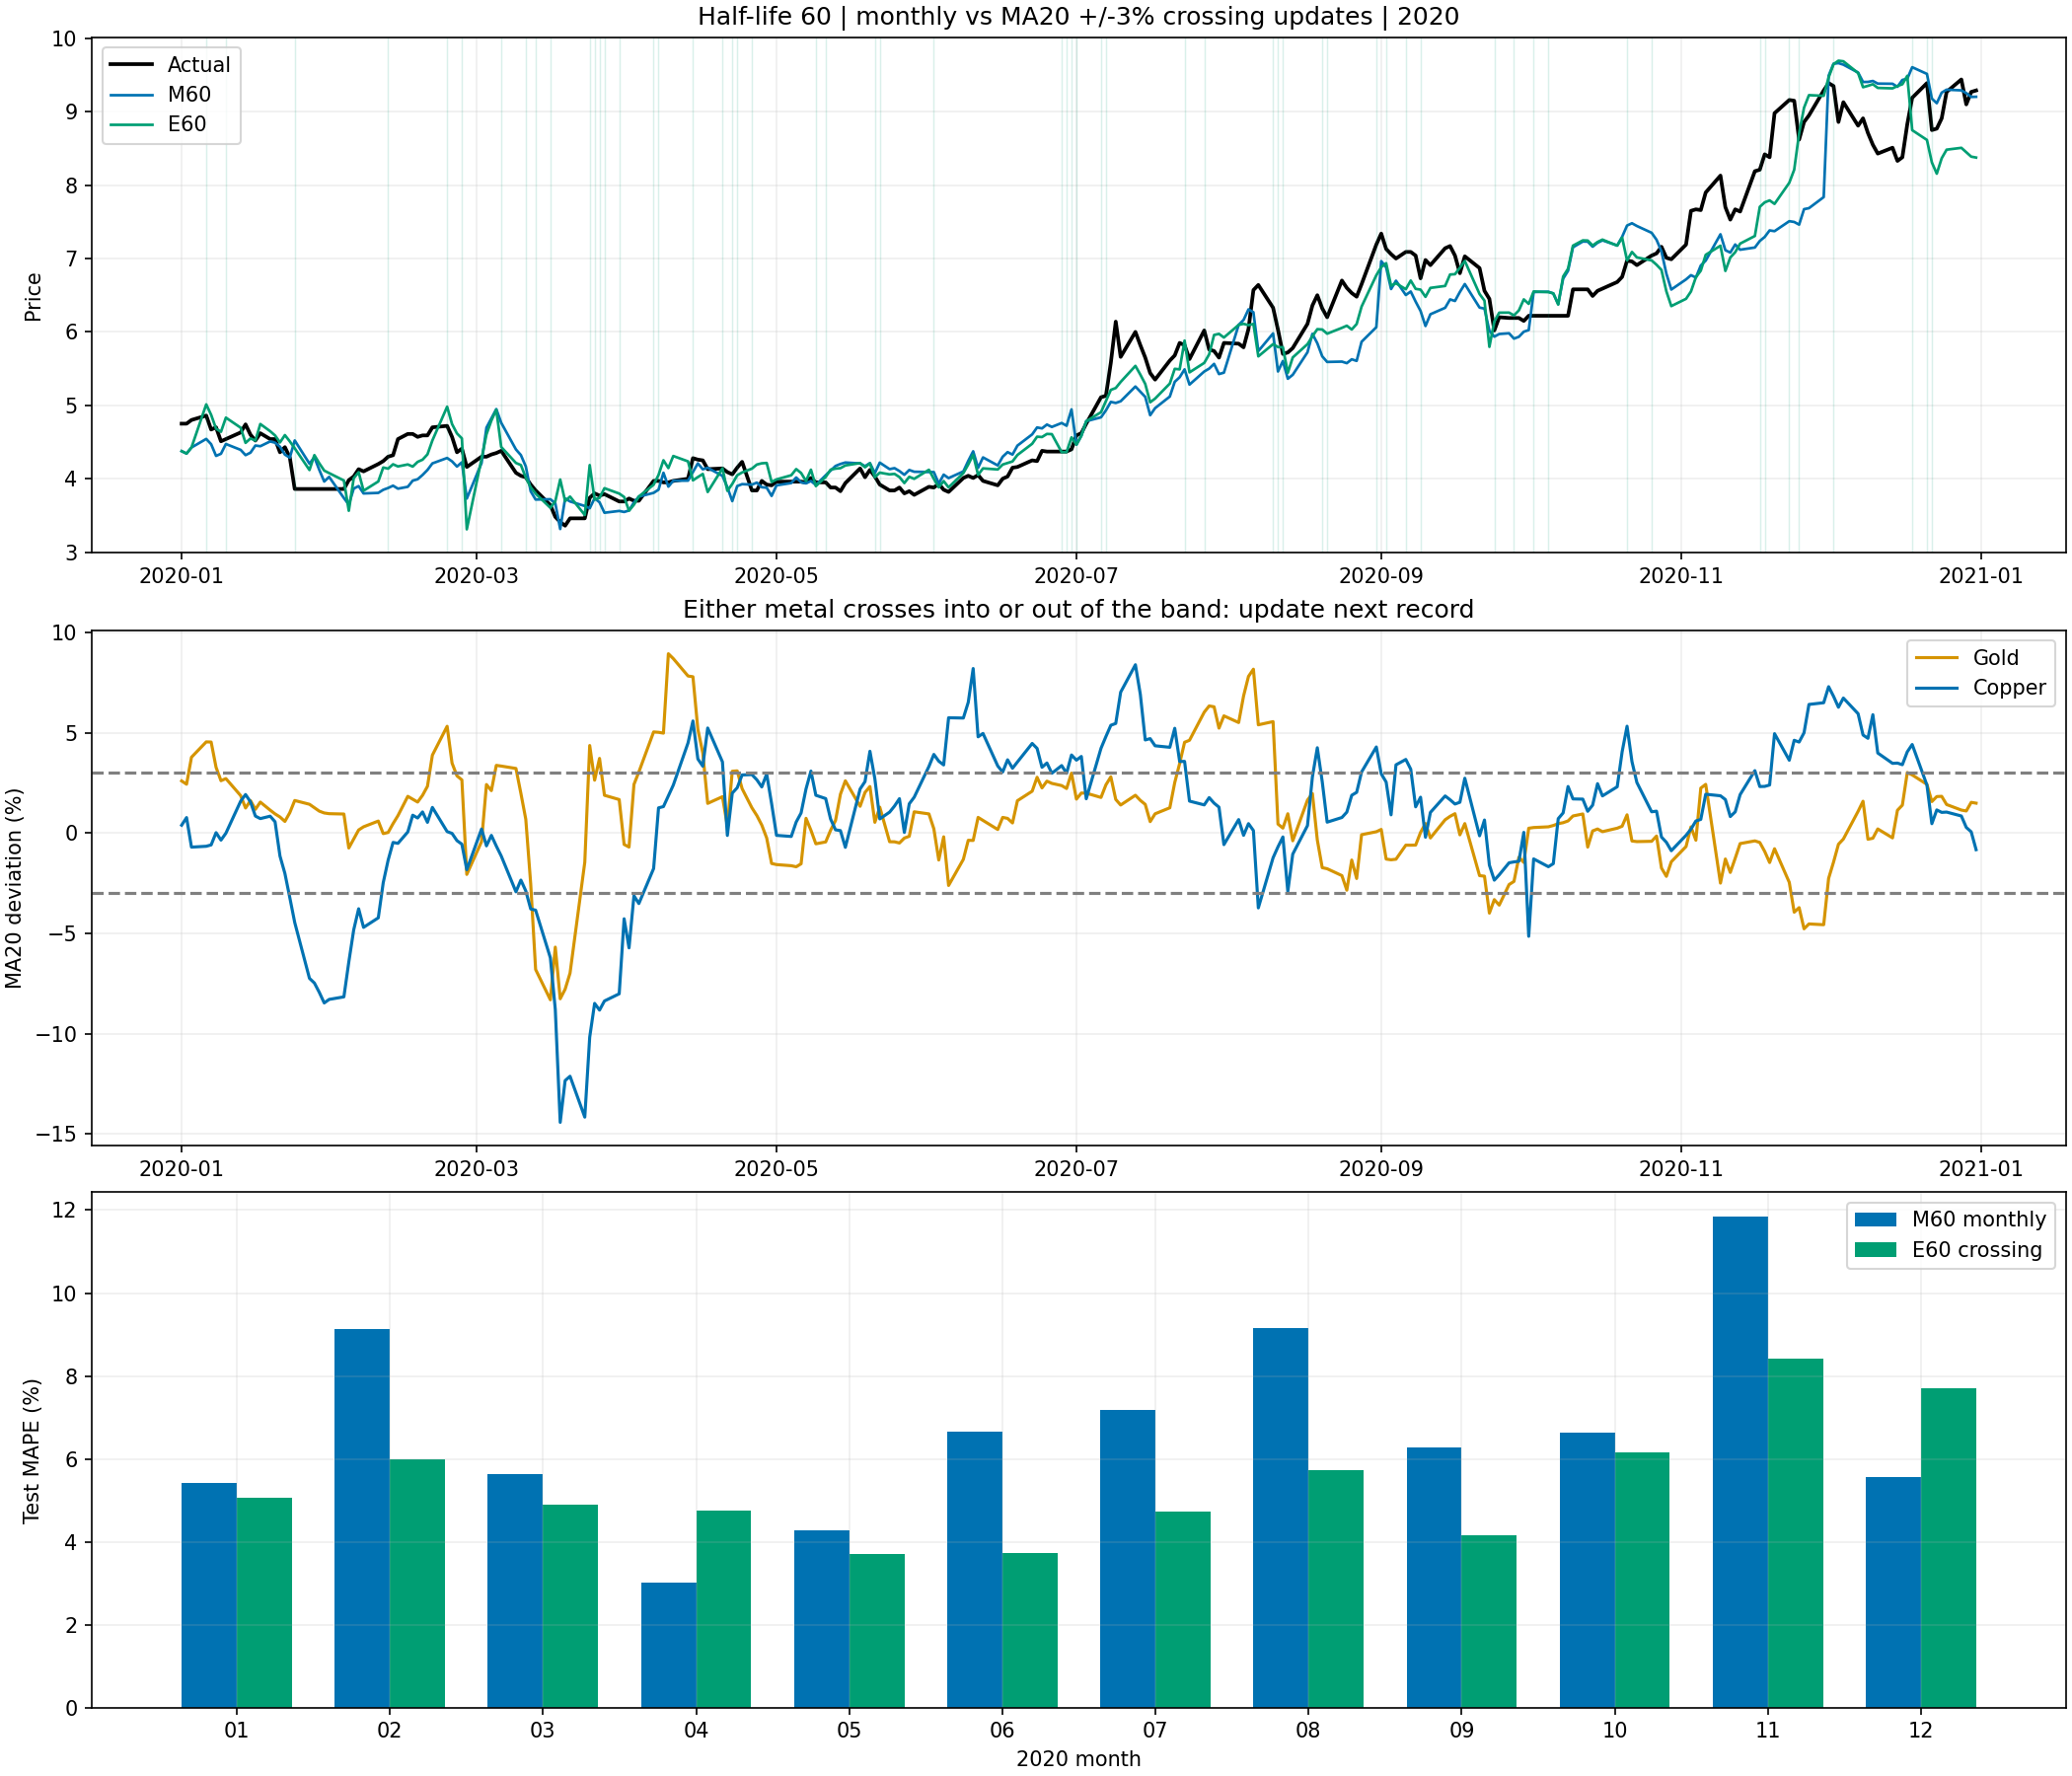

In [4]:
fig,axes=plt.subplots(3,1,figsize=(14,12),constrained_layout=True)
axes[0].plot(comparison.Date,comparison.Actual,color='black',lw=1.8,label='Actual')
for m,color in [('M60','#0072B2'),('E60','#009E73')]:axes[0].plot(comparison.Date,comparison[m],color=color,lw=1.3,label=m)
for dt in schedule.Effective_date.iloc[1:]:axes[0].axvline(dt,color='#009E73',alpha=.15,lw=.7)
axes[0].set(title='Half-life 60 | monthly vs MA20 +/-3% crossing updates | 2020',ylabel='Price');axes[0].legend()
for metal,col,color in [('Gold','gold_vs_ma20','#D59400'),('Copper','copper_vs_ma20','#0072B2')]:axes[1].plot(whole,x.loc[whole,col]*100,color=color,label=metal)
for v in [-3,3]:axes[1].axhline(v,color='gray',ls='--')
axes[1].set(ylabel='MA20 deviation (%)',title='Either metal crosses into or out of the band: update next record');axes[1].legend()
pos=np.arange(12)
axes[2].bar(pos-.18,monthly.M60_MAPE,width=.36,color='#0072B2',label='M60 monthly')
axes[2].bar(pos+.18,monthly.E60_MAPE,width=.36,color='#009E73',label='E60 crossing')
axes[2].set(xticks=pos,xticklabels=monthly.Month.str[-2:],ylabel='Test MAPE (%)',xlabel='2020 month');axes[2].legend()
for ax in axes:ax.grid(alpha=.2)
fig.savefig(OUT/'comparison.png',dpi=150);plt.close(fig);display(Image(filename=str(OUT/'comparison.png')))


## 本轮结果

| 方案 | 全年MAPE | 普通MSE | 最差月份MAPE | 年内重训次数（不含初始化） |
|---|---:|---:|---:|---:|
| A 月度等权 | 8.1499% | 0.338087 | 14.0170% | 11 |
| 等权3%双向触发 | 6.3819% | 0.211321 | 10.8738% | 58 |
| M60 月度更新 | 6.6577% | 0.250269 | 11.8386% | 11 |
| E60 3%双向触发 | **5.3870%** | **0.168516** | **8.4098%** | 58 |

E60相对M60，全年MAPE降低1.2707个百分点，普通MSE降低32.67%。10/12个月的MAPE和MSE改善；4月MAPE由3.02%升至4.76%，12月由5.57%升至7.71%。相对原等权触发策略，E60的全年MAPE也降低0.9949个百分点。

**当前实验中，半衰期60结合3%双向触发的总体误差更低。** 但它部署59个模型（月度12个，均含初始化），并不能单凭本次比较证明3%阈值本身优于同等更新次数的固定周期；种子也随各自历史验证窗口变化。更频繁重训亦不保证预测曲线消除跳变，不能把误差下降等同于平滑性改善。

触发重训每次均使用截至触发日的信息，下一条记录才生效。年初首段预测与M60一致，触发日程与12完全一致；118个阶段模型、11800条逐轮记录、271条对齐测试记录检查通过。模型、逐月指标、更新日期和同输入下新旧模型切换差值均保存于本节结果目录。


### 从20年来看,我们认为多次更新,加上权重MSE更好的适应趋势,跟上变化.下面我们再用15到26年进行测试,看看是否验证这个结论.